In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv(r'C:\Projects\Loan-Approval-Project\data\raw\Loan.csv')

In [47]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [49]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [52]:
for i in df.columns:
  print(df[i].value_counts(),'\n')

Loan_ID
LP002990    1
LP001002    1
LP001003    1
LP001005    1
LP001006    1
           ..
LP001024    1
LP001020    1
LP001018    1
LP001014    1
LP001013    1
Name: count, Length: 614, dtype: int64 

Gender
Male      489
Female    112
Name: count, dtype: int64 

Married
Yes    398
No     213
Name: count, dtype: int64 

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64 

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64 

Self_Employed
No     500
Yes     82
Name: count, dtype: int64 

ApplicantIncome
2500     9
4583     6
6000     6
2600     6
3750     5
        ..
7660     1
5955     1
3365     1
2799     1
12841    1
Name: count, Length: 505, dtype: int64 

CoapplicantIncome
0.0       273
1666.0      5
2083.0      5
2500.0      5
1625.0      3
         ... 
2232.0      1
2739.0      1
2210.0      1
461.0       1
2336.0      1
Name: count, Length: 287, dtype: int64 

LoanAmount
120.0    20
110.0    17
100.0    15
187.0    12
160.0

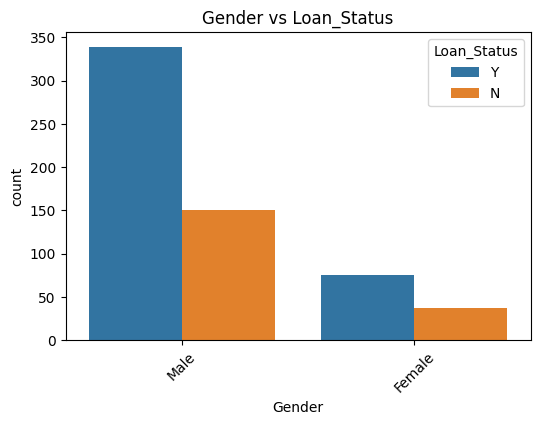

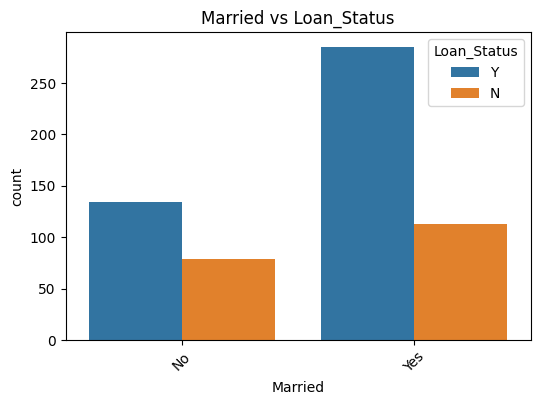

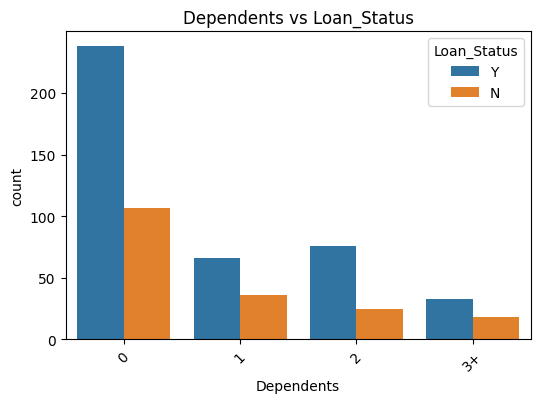

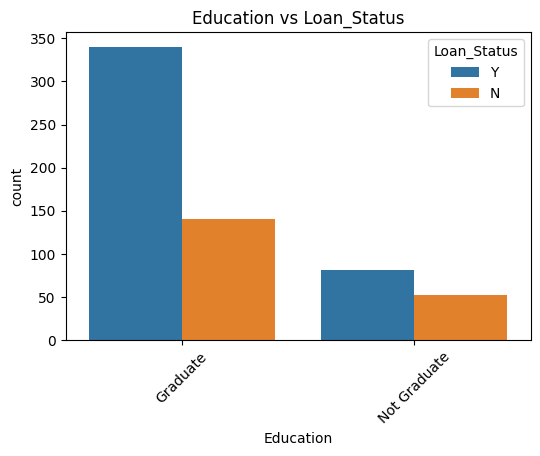

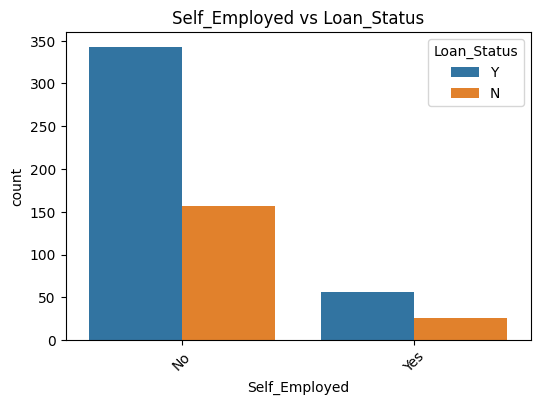

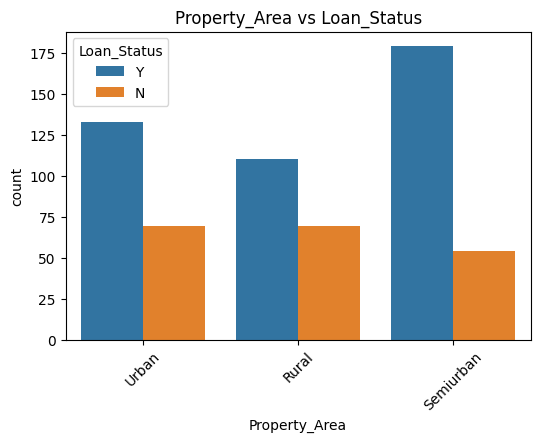

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='Loan_Status')
    plt.title(f"{col} vs Loan_Status")
    plt.xticks(rotation=45)
    plt.show()

In [54]:
for col in df.columns:
    print(col, df[col].nunique())

Loan_ID 614
Gender 2
Married 2
Dependents 4
Education 2
Self_Employed 2
ApplicantIncome 505
CoapplicantIncome 287
LoanAmount 203
Loan_Amount_Term 10
Credit_History 2
Property_Area 3
Loan_Status 2


In [55]:
df.select_dtypes(include=['int64','float64']).skew()

ApplicantIncome      6.539513
CoapplicantIncome    7.491531
LoanAmount           2.677552
Loan_Amount_Term    -2.362414
Credit_History      -1.882361
dtype: float64

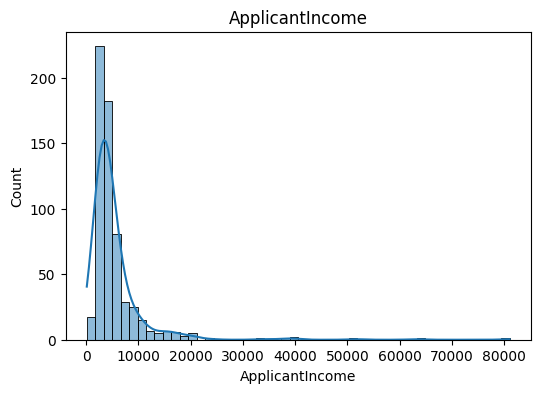

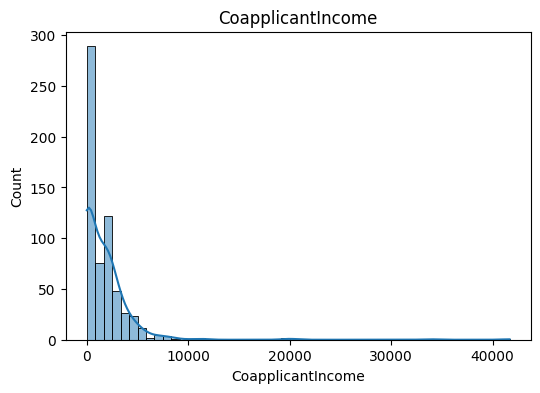

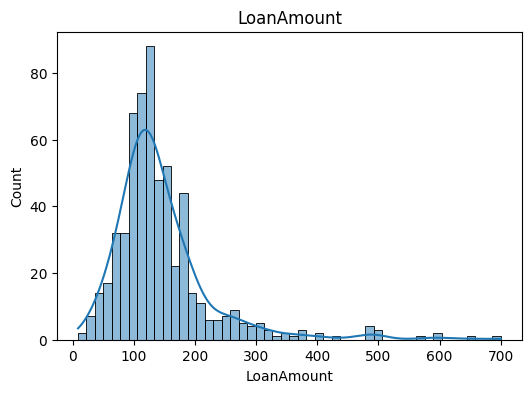

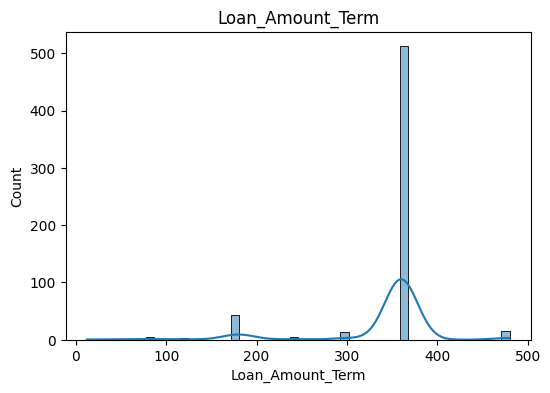

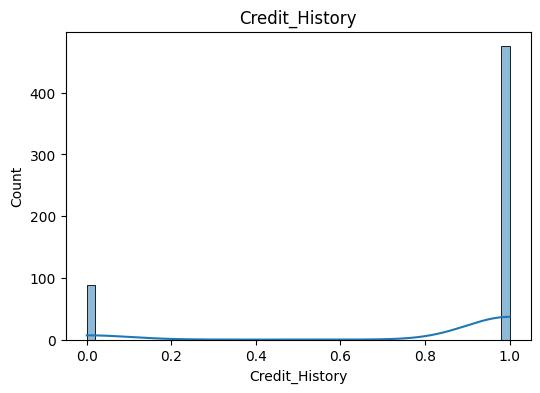

In [56]:
#Skewed Data Analysis
for col in df.select_dtypes(include=['int64','float64']).columns:
  plt.figure(figsize=(6,4))
  sns.histplot(data=df,x=col, bins=50, kde=True)
  plt.title(f"{col}" )
  plt.show()

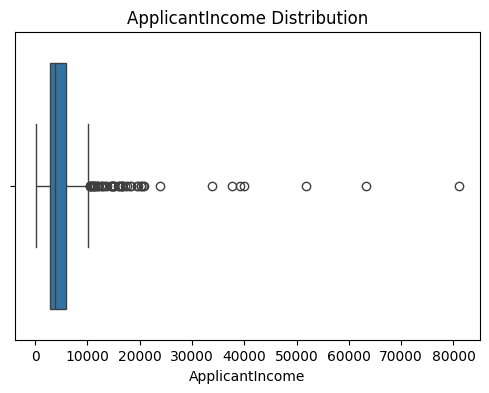

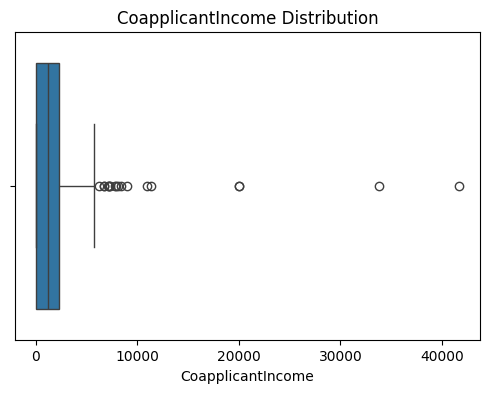

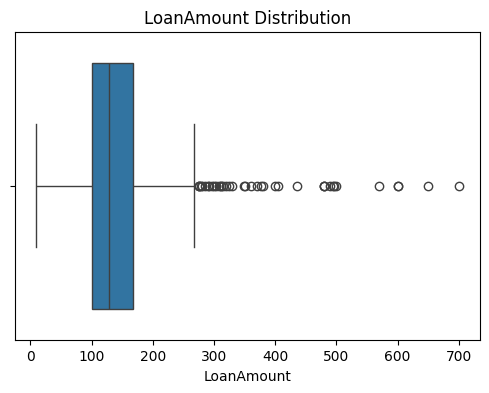

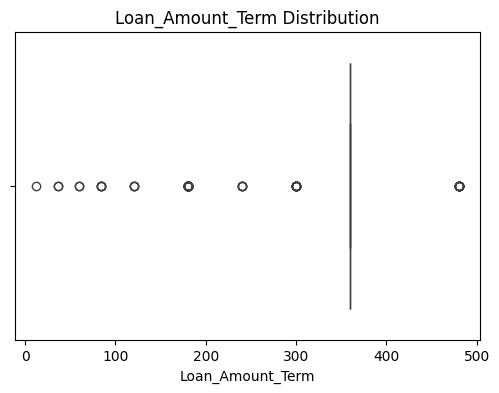

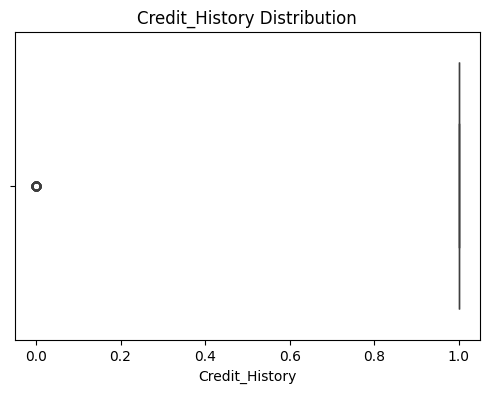

In [57]:
#Outlier Analysis
for col in df.select_dtypes(include=['int64','float64']).columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(data=df,x=col)
  plt.title(f"{col} Distribution" )
  plt.show()

In [58]:
df2=df.copy()
df2['Loan_Status'] = df2['Loan_Status'].map({'N':0,'Y':1})
df2.corr(numeric_only=True)['Loan_Status']

ApplicantIncome     -0.004710
CoapplicantIncome   -0.059187
LoanAmount          -0.037318
Loan_Amount_Term    -0.021268
Credit_History       0.561678
Loan_Status          1.000000
Name: Loan_Status, dtype: float64

In [59]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Loan_Status',axis=1),df['Loan_Status'],test_size=0.2,stratify=df['Loan_Status'],random_state=42)

In [60]:
# Create a binary feature: 1 if there is a co-applicant, 0 if not
X_train['Has_Coapplicant'] = (X_train['CoapplicantIncome'] > 0).astype(int)
X_test['Has_Coapplicant'] = (X_test['CoapplicantIncome'] > 0).astype(int)

In [61]:

numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education',
                    'Self_Employed', 'Credit_History', 'Loan_Amount_Term']

for col in numerical_cols:
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

for col in categorical_cols:
    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

print("Remaining missing values in Train:", X_train.isnull().sum().sum())
print("Remaining missing values in Test:", X_test.isnull().sum().sum())

Remaining missing values in Train: 0
Remaining missing values in Test: 0


In [62]:
continuous_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
for col in continuous_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)


    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

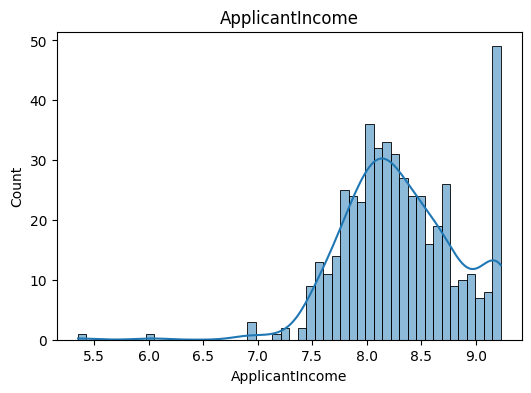

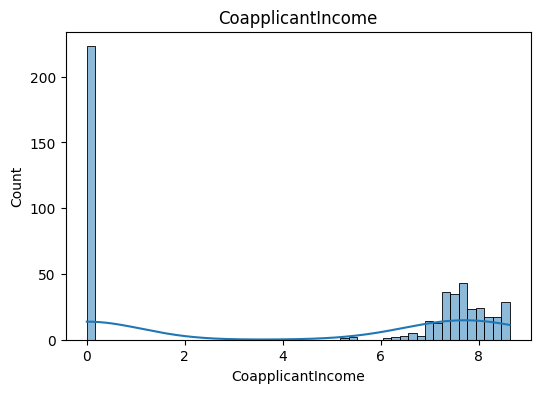

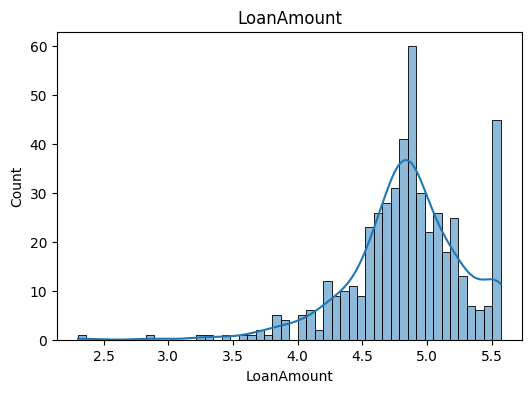

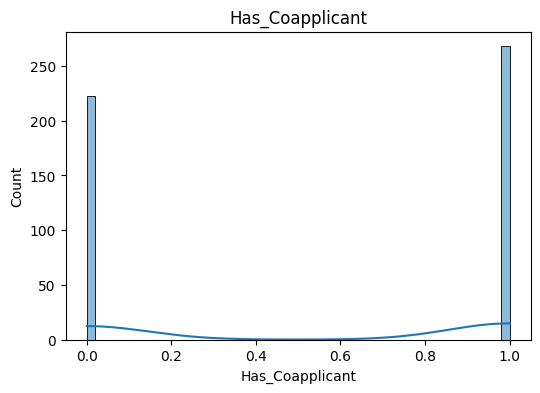

In [63]:
#After Handling Skewed Data and Outliers
for col in X_train.select_dtypes(include=['int64','float64']).columns:
  if col in set(["Credit_History","Loan_Amount_Term"]):
    continue
  plt.figure(figsize=(6,4))
  sns.histplot(data=X_train,x=col, bins=50, kde=True)
  plt.title(f"{col}" )
  plt.show()

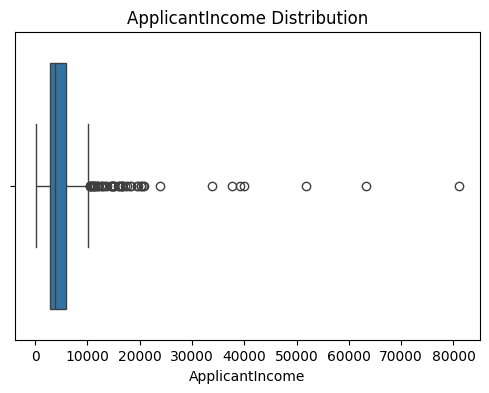

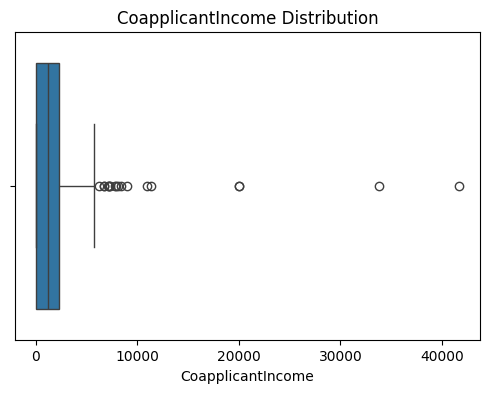

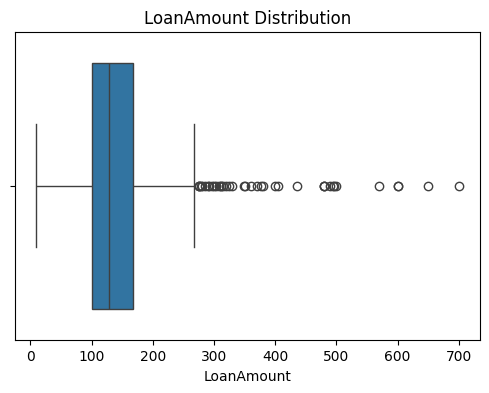

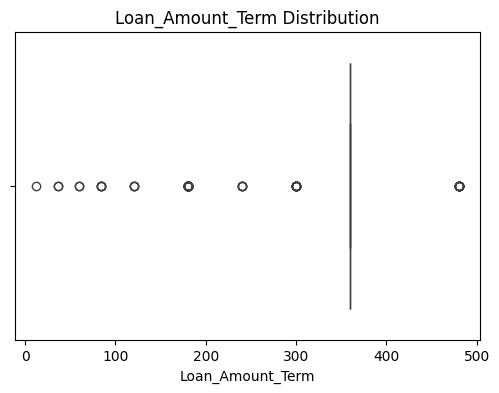

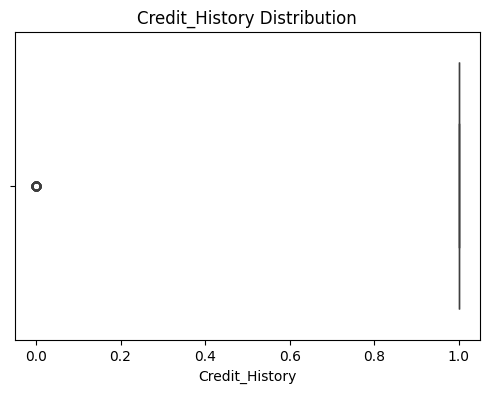

In [64]:
for col in df.select_dtypes(include=['int64','float64']).columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(data=df,x=col)
  plt.title(f"{col} Distribution" )
  plt.show()

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ["Gender", "Married", "Dependents","Education","Self_Employed"]
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount","Loan_Amount_Term","Credit_History"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [67]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [68]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_transformed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [69]:
y_pred = model.predict(X_test_transformed)

In [70]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8536585365853658
[[21 17]
 [ 1 84]]
              precision    recall  f1-score   support

           N       0.95      0.55      0.70        38
           Y       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [72]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [73]:
from sklearn.model_selection import cross_val_score
results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_transformed,
        y_train,
        cv=5,              # 5-fold CV
        scoring="accuracy"
    )

    results[name] = np.mean(scores)

    print(f"{name}")
    print("Scores:", scores)
    print("Mean Accuracy:", np.mean(scores))
    print("-" * 40)

Logistic Regression
Scores: [0.7979798  0.80612245 0.80612245 0.78571429 0.78571429]
Mean Accuracy: 0.7963306534735106
----------------------------------------
Decision Tree
Scores: [0.68686869 0.67346939 0.66326531 0.67346939 0.74489796]
Mean Accuracy: 0.6883941455370026
----------------------------------------
Random Forest
Scores: [0.75757576 0.81632653 0.7755102  0.73469388 0.75510204]
Mean Accuracy: 0.7678416821273963
----------------------------------------
SVM
Scores: [0.7979798  0.79591837 0.81632653 0.78571429 0.78571429]
Mean Accuracy: 0.7963306534735105
----------------------------------------
KNN
Scores: [0.77777778 0.74489796 0.79591837 0.73469388 0.73469388]
Mean Accuracy: 0.7575963718820862
----------------------------------------


In [74]:
best_model = max(results, key=results.get)

print("\nBEST MODEL:", best_model)
print("BEST CV ACCURACY:", results[best_model])


BEST MODEL: Logistic Regression
BEST CV ACCURACY: 0.7963306534735106


In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
svm = SVC(class_weight="balanced")

In [76]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

In [77]:

grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_transformed, y_train)

,estimator,SVC(class_weight='balanced')
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [78]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy: 0.7983714698000413


In [79]:
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_transformed)

In [80]:
from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8536585365853658
              precision    recall  f1-score   support

           N       0.95      0.55      0.70        38
           Y       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [81]:
# convert target first
y_train = y_train.map({'N':0, 'Y':1})
y_test = y_test.map({'N':0, 'Y':1})